# 02. Data Preprocessing

**Objectives:**
- Load raw banking data
- Clean and preprocess OHLCV data
- Add technical indicators
- Prepare data for agent analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('default')
sns.set_palette('husl')

In [2]:
# Load the raw data
data_path = '../data/banking_ohlcv_raw.csv'
df = pd.read_csv(data_path, header=[0, 1], index_col=0)
df.index = pd.to_datetime(df.index)

print("Data shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Date range:", df.index.min(), "to", df.index.max())
df.head()

Data shape: (731, 36)
Columns: [('COMB.N0000.LK', 'Open'), ('COMB.N0000.LK', 'High'), ('COMB.N0000.LK', 'Low'), ('COMB.N0000.LK', 'Close'), ('COMB.N0000.LK', 'Adj Close'), ('COMB.N0000.LK', 'Volume'), ('HNB.N0000.LK', 'Open'), ('HNB.N0000.LK', 'High'), ('HNB.N0000.LK', 'Low'), ('HNB.N0000.LK', 'Close'), ('HNB.N0000.LK', 'Adj Close'), ('HNB.N0000.LK', 'Volume'), ('NDB.N0000.LK', 'Open'), ('NDB.N0000.LK', 'High'), ('NDB.N0000.LK', 'Low'), ('NDB.N0000.LK', 'Close'), ('NDB.N0000.LK', 'Adj Close'), ('NDB.N0000.LK', 'Volume'), ('DFCC.N0000.LK', 'Open'), ('DFCC.N0000.LK', 'High'), ('DFCC.N0000.LK', 'Low'), ('DFCC.N0000.LK', 'Close'), ('DFCC.N0000.LK', 'Adj Close'), ('DFCC.N0000.LK', 'Volume'), ('SAMP.N0000.LK', 'Open'), ('SAMP.N0000.LK', 'High'), ('SAMP.N0000.LK', 'Low'), ('SAMP.N0000.LK', 'Close'), ('SAMP.N0000.LK', 'Adj Close'), ('SAMP.N0000.LK', 'Volume'), ('BFLN.N0000.LK', 'Open'), ('BFLN.N0000.LK', 'High'), ('BFLN.N0000.LK', 'Low'), ('BFLN.N0000.LK', 'Close'), ('BFLN.N0000.LK', 'Adj Clos

COMB.N0000.LK                                        HNB.N0000.LK  \
                    Open   High    Low  Close Adj Close  Volume         Open   
Date                                                                           
2024-03-21         89.52  89.92  88.71  89.18     89.18   15161       154.72   
2024-03-22         89.38  93.77  86.25  86.85     86.85  111476       153.05   
2024-03-23         87.14  93.40  85.64  87.02     87.02  179601       158.68   
2024-03-24         87.86  93.91  85.66  89.68     89.68   51061       154.93   
2024-03-25         90.18  90.81  89.58  90.71     90.71  159764       156.99   

                                    ... SAMP.N0000.LK                   \
              High     Low   Close  ...           Low  Close Adj Close   
Date                                ...                                  
2024-03-21  155.96  153.09  153.87  ...         71.95  72.48     72.48   
2024-03-22  161.49  150.33  158.79  ...         72.09  74.10     74.10   
2024-03-23  163.55  146.76  153.82  ...         69.21  72.26     72.26   
2024-03-24  157.76  153.29  156.01  ...         71.67  71.95     71.95   
2024-03-25  159.59  152.59  156.47  ...         70.59  70.63     70.63   

                   BFLN.N0000.LK                                         
            Volume          Open   High    Low  Close Adj Close  Volume  
Date                                                                     
2024-03-21  154419         49.39  50.01  49.05  49.89     49.89   33472  
2024-03-22   45977         49.69  50.22  48.96  49.54     49.54  128203  
2024-03-23  149781         49.29  51.26  48.09  51.17     51.17   28177  
2024-03-24  173530         50.79  51.55  50.48  51.13     51.13   84793  
2024-03-25  177771         51.40  53.63  50.63  52.78     52.78   39273  

[5 rows x 36 columns]

In [3]:
# Clean data - remove any NaN values
df_clean = df.dropna()
print(f"Original shape: {df.shape}, Cleaned shape: {df_clean.shape}")

# Check for any remaining issues
print("Missing values per column:")
print(df_clean.isnull().sum())

Original shape: (731, 36), Cleaned shape: (731, 36)
Missing values per column:
COMB.N0000.LK  Open         0
               High         0
               Low          0
               Close        0
               Adj Close    0
               Volume       0
HNB.N0000.LK   Open         0
               High         0
               Low          0
               Close        0
               Adj Close    0
               Volume       0
NDB.N0000.LK   Open         0
               High         0
               Low          0
               Close        0
               Adj Close    0
               Volume       0
DFCC.N0000.LK  Open         0
               High         0
               Low          0
               Close        0
               Adj Close    0
               Volume       0
SAMP.N0000.LK  Open         0
               High         0
               Low          0
               Close        0
               Adj Close    0
               Volume       0
BFLN.N0000.LK  Open  

In [4]:
def add_technical_indicators(df, ticker):
    """Add technical indicators for a single ticker"""
    data = df[ticker].copy()
    
    # Simple Moving Averages
    data['SMA_20'] = data['Close'].rolling(window=20).mean()
    data['SMA_50'] = data['Close'].rolling(window=50).mean()
    
    # Exponential Moving Averages
    data['EMA_12'] = data['Close'].ewm(span=12).mean()
    data['EMA_26'] = data['Close'].ewm(span=26).mean()
    
    # MACD
    data['MACD'] = data['EMA_12'] - data['EMA_26']
    data['Signal_Line'] = data['MACD'].ewm(span=9).mean()
    
    # RSI
    delta = data['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    data['RSI'] = 100 - (100 / (1 + rs))
    
    # Bollinger Bands
    data['BB_Middle'] = data['Close'].rolling(window=20).mean()
    data['BB_Upper'] = data['BB_Middle'] + 2 * data['Close'].rolling(window=20).std()
    data['BB_Lower'] = data['BB_Middle'] - 2 * data['Close'].rolling(window=20).std()
    
    # Daily returns
    data['Daily_Return'] = data['Close'].pct_change()
    
    # Volatility (20-day rolling std of returns)
    data['Volatility'] = data['Daily_Return'].rolling(window=20).std()
    
    return data

# Apply to all tickers
tickers = ['COMB.N0000.LK', 'HNB.N0000.LK', 'NDB.N0000.LK', 'BFLN.N0000.LK', 'DFCC.N0000.LK', 'SAMP.N0000.LK']
processed_data = {}

for ticker in tickers:
    if ticker in df_clean.columns.levels[0]:
        processed_data[ticker] = add_technical_indicators(df_clean, ticker)
        print(f"Processed {ticker}")
    else:
        print(f"Ticker {ticker} not found in data")

# Combine back
df_processed = pd.concat(processed_data, axis=1, keys=tickers)
print(f"Processed data shape: {df_processed.shape}")

Processed COMB.N0000.LK
Processed HNB.N0000.LK
Processed NDB.N0000.LK
Processed BFLN.N0000.LK
Processed DFCC.N0000.LK
Processed SAMP.N0000.LK
Processed data shape: (731, 108)


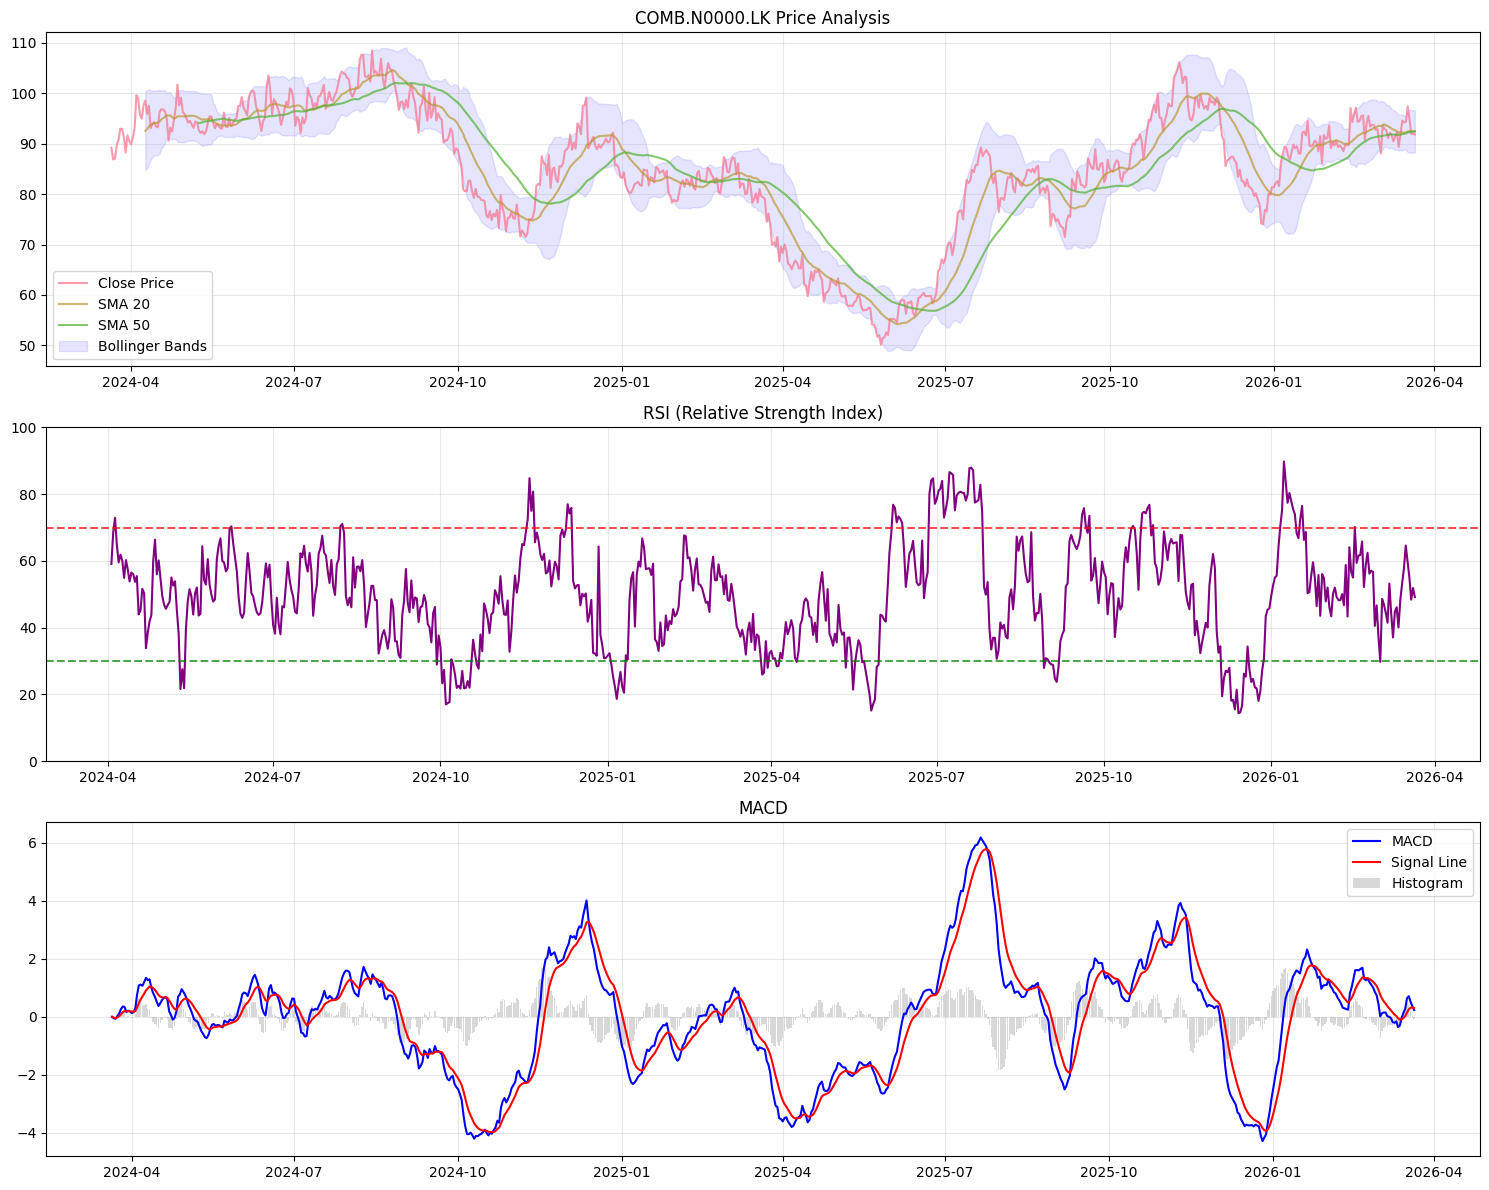

In [5]:
# Visualize one ticker's data
ticker = 'COMB.N0000.LK'
if ticker in processed_data:
    fig, axes = plt.subplots(3, 1, figsize=(15, 12))
    
    # Price chart with moving averages
    axes[0].plot(processed_data[ticker]['Close'], label='Close Price', alpha=0.7)
    axes[0].plot(processed_data[ticker]['SMA_20'], label='SMA 20', alpha=0.7)
    axes[0].plot(processed_data[ticker]['SMA_50'], label='SMA 50', alpha=0.7)
    axes[0].fill_between(processed_data[ticker].index, 
                        processed_data[ticker]['BB_Lower'], 
                        processed_data[ticker]['BB_Upper'], 
                        alpha=0.1, color='blue', label='Bollinger Bands')
    axes[0].set_title(f'{ticker} Price Analysis')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # RSI
    axes[1].plot(processed_data[ticker]['RSI'], color='purple')
    axes[1].axhline(y=70, color='r', linestyle='--', alpha=0.7)
    axes[1].axhline(y=30, color='g', linestyle='--', alpha=0.7)
    axes[1].set_title('RSI (Relative Strength Index)')
    axes[1].set_ylim(0, 100)
    axes[1].grid(True, alpha=0.3)
    
    # MACD
    axes[2].plot(processed_data[ticker]['MACD'], label='MACD', color='blue')
    axes[2].plot(processed_data[ticker]['Signal_Line'], label='Signal Line', color='red')
    axes[2].bar(processed_data[ticker].index, 
               processed_data[ticker]['MACD'] - processed_data[ticker]['Signal_Line'], 
               alpha=0.3, color='gray', label='Histogram')
    axes[2].set_title('MACD')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Ticker {ticker} not available for visualization")

In [6]:
# Save processed data
output_path = '../data/banking_processed.csv'
df_processed.to_csv(output_path)
print(f"Processed data saved to {output_path}")

# Summary statistics
print("\nSummary of processed data:")
for ticker in tickers:
    if ticker in processed_data:
        print(f"\n{ticker}:")
        print(f"  Records: {len(processed_data[ticker])}")
        print(f"  Avg Close: {processed_data[ticker]['Close'].mean():.2f}")
        print(f"  Volatility: {processed_data[ticker]['Volatility'].mean():.4f}")

Processed data saved to ../data/banking_processed.csv

Summary of processed data:

COMB.N0000.LK:
  Records: 731
  Avg Close: 85.23
  Volatility: 0.0249

HNB.N0000.LK:
  Records: 731
  Avg Close: 89.90
  Volatility: 0.0256

NDB.N0000.LK:
  Records: 731
  Avg Close: 39.09
  Volatility: 0.0256

BFLN.N0000.LK:
  Records: 731
  Avg Close: 87.37
  Volatility: 0.0252

DFCC.N0000.LK:
  Records: 731
  Avg Close: 102.36
  Volatility: 0.0257

SAMP.N0000.LK:
  Records: 731
  Avg Close: 37.53
  Volatility: 0.0256


🧠 Starting K-Means Clustering Analysis...


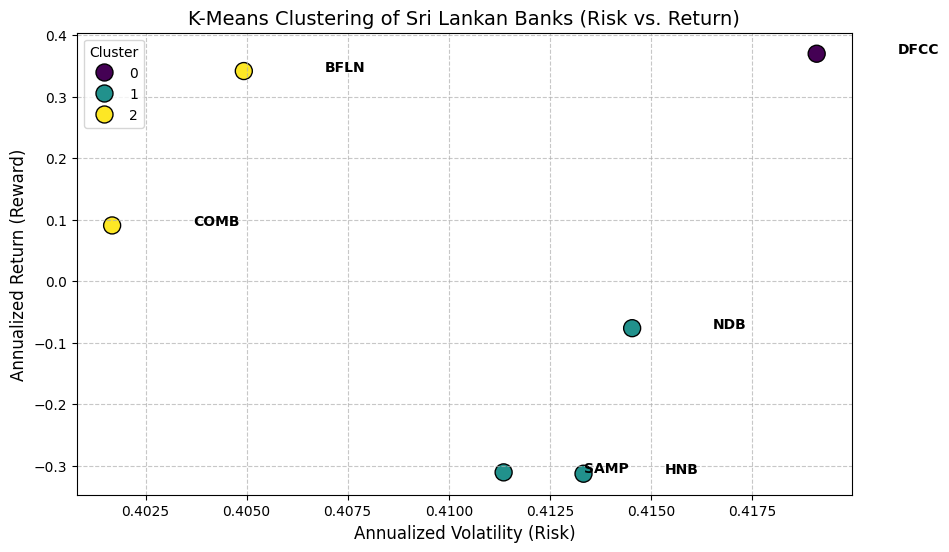

✅ Clustering complete! Plot saved to data folder.


,Annual_Return,Volatility,Cluster
Ticker,,,
BFLN.N0000.LK,0.341666,0.404931,2
COMB.N0000.LK,0.090581,0.401674,2
DFCC.N0000.LK,0.369853,0.419100,0
HNB.N0000.LK,-0.313228,0.413333,1
NDB.N0000.LK,-0.076523,0.414536,1
SAMP.N0000.LK,-0.311034,0.411357,1


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("🧠 Starting K-Means Clustering Analysis...")

clustering_data = []

# 1. Extract risk/return metrics for each bank

for ticker in df_clean.columns.levels[0]:
    if 'Close' in df_clean[ticker]:
        # Calculate daily percentage change
        daily_returns = df_clean[ticker]['Close'].pct_change().dropna()
        
        # Annualize the returns and volatility (assuming ~252 trading days in a year)
        avg_return = daily_returns.mean() * 252 
        volatility = daily_returns.std() * np.sqrt(252) 
        
        clustering_data.append({
            'Ticker': ticker,
            'Annual_Return': avg_return,
            'Volatility': volatility
        })

cluster_df = pd.DataFrame(clustering_data).set_index('Ticker')

# 2. Scale the features (K-Means requires normalized data)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_df)

# 3. Apply K-Means (Grouping into 3 clusters: e.g., High Risk, Med Risk, Low Risk)
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_df['Cluster'] = kmeans.fit_predict(scaled_features)

# 4. Visualize the Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=cluster_df, 
    x='Volatility', 
    y='Annual_Return', 
    hue='Cluster', 
    palette='viridis', 
    s=150,
    edgecolor='black'
)

# Add Ticker labels to the points so we know which bank is which
for i in range(cluster_df.shape[0]):
    plt.text(
        cluster_df['Volatility'].iloc[i] + 0.002, 
        cluster_df['Annual_Return'].iloc[i], 
        cluster_df.index[i].replace('.N0000.LK', ''), # Cleaning up the label for the chart
        fontsize=10,
        fontweight='bold'
    )

plt.title('K-Means Clustering of Sri Lankan Banks (Risk vs. Return)', fontsize=14)
plt.xlabel('Annualized Volatility (Risk)', fontsize=12)
plt.ylabel('Annualized Return (Reward)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Save the plot for your final report!
import os
if not os.path.exists('../data'):
    os.makedirs('../data')
plt.savefig('../data/kmeans_clusters.png', bbox_inches='tight')
plt.show()

print("✅ Clustering complete! Plot saved to data folder.")
display(cluster_df)